# Student Mental Health Analysis During Online Learning

## Introduction
This notebook analyzes the mental health of students during online learning, using a dataset containing information about demographics, screen time, sleep duration, physical activity, stress levels, and academic performance. The goal is to uncover patterns and insights that can help understand the impact of online learning on student well-being.

## Table of Contents
1. Data Loading and Overview
2. Data Cleaning and Preparation
3. Exploratory Data Analysis (EDA)
4. Key Insights
5. Visualizations
6. Conclusion

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Overview

In [3]:
df=pd.read_csv("Student Mental Health Analysis During Online Learning.csv")
df.head()

,Name,Gender,Age,Education Level,Screen Time (hrs/day),Sleep Duration (hrs),Physical Activity (hrs/week),Stress Level,Anxious Before Exams,Academic Performance Change
0,Aarav,Male,15,Class 8,7.1,8.9,9.3,Medium,No,Same
1,Meera,Female,25,MSc,3.3,5.0,0.2,Medium,No,Same
2,Ishaan,Male,20,BTech,9.5,5.4,6.2,Medium,No,Same
3,Aditya,Male,20,BA,10.8,5.6,5.5,High,Yes,Same
4,Anika,Female,17,Class 11,2.8,5.4,3.1,Medium,Yes,Same


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Name                          1000 non-null   object 
 1   Gender                        1000 non-null   object 
 2   Age                           1000 non-null   int64  
 3   Education Level               1000 non-null   object 
 4   Screen Time (hrs/day)         1000 non-null   float64
 5   Sleep Duration (hrs)          1000 non-null   float64
 6   Physical Activity (hrs/week)  1000 non-null   float64
 7   Stress Level                  1000 non-null   object 
 8   Anxious Before Exams          1000 non-null   object 
 9   Academic Performance Change   1000 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 78.3+ KB


In [5]:
df.describe()

,Age,Screen Time (hrs/day),Sleep Duration (hrs),Physical Activity (hrs/week)
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.342000,6.909200,6.450800,5.017600
std,3.459914,2.907106,1.466407,2.930344
min,15.000000,2.000000,4.000000,0.000000
25%,17.000000,4.400000,5.100000,2.600000
50%,20.000000,6.900000,6.500000,5.000000
75%,23.000000,9.500000,7.700000,7.600000
max,26.000000,12.000000,9.000000,10.000000


In [6]:
df.columns

Index(['Name', 'Gender', 'Age', 'Education Level', 'Screen Time (hrs/day)',
       'Sleep Duration (hrs)', 'Physical Activity (hrs/week)', 'Stress Level',
       'Anxious Before Exams', 'Academic Performance Change'],
      dtype='object')

## Data Cleaning and Preparation

In [7]:
df.isnull().sum()


Name                            0
Gender                          0
Age                             0
Education Level                 0
Screen Time (hrs/day)           0
Sleep Duration (hrs)            0
Physical Activity (hrs/week)    0
Stress Level                    0
Anxious Before Exams            0
Academic Performance Change     0
dtype: int64

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.columns= [col.replace(" ","_").lower() for col in df.columns]

### Exploratory Data Analysis (EDA)

In [10]:
edu_levels=df["education_level"].value_counts()
edu_levels.head()

education_level
MTech       143
MSc         138
MA          129
Class 11     88
Class 9      87
Name: count, dtype: int64

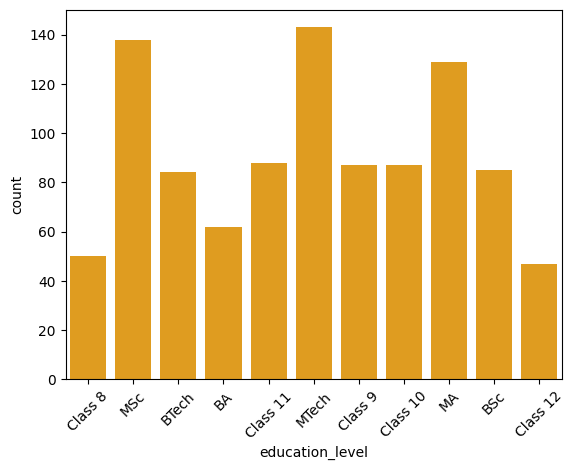

In [11]:
sns.countplot(data=df, x="education_level",color="orange")
plt.xticks(rotation=45)
plt.show()

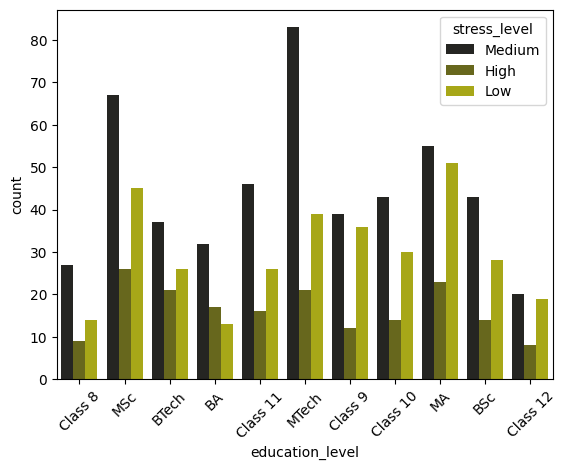

In [12]:
sns.countplot(data=df,x="education_level",palette="dark:y",hue="stress_level")
plt.xticks(rotation=45)
plt.show()

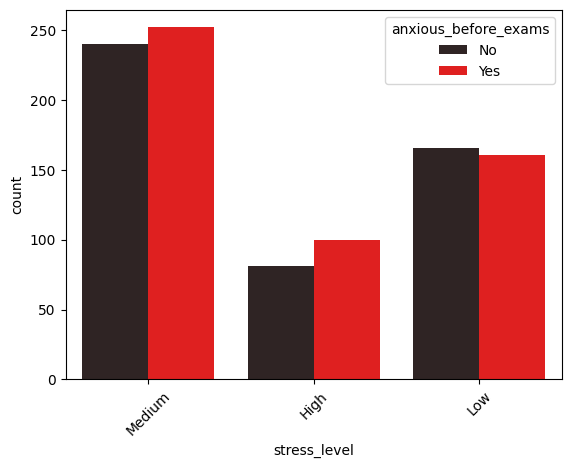

In [13]:
sns.countplot(data=df,x="stress_level",hue="anxious_before_exams",palette="dark:r")
plt.xticks(rotation=45)
plt.show()

In [14]:
def remove_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    filtered_out = df[(df[col] > low) & (df[col] < high)]
    return filtered_out

numeric_col = df.select_dtypes(include='number').columns
for col in numeric_col:
    removed_out = remove_outliers(df, col)




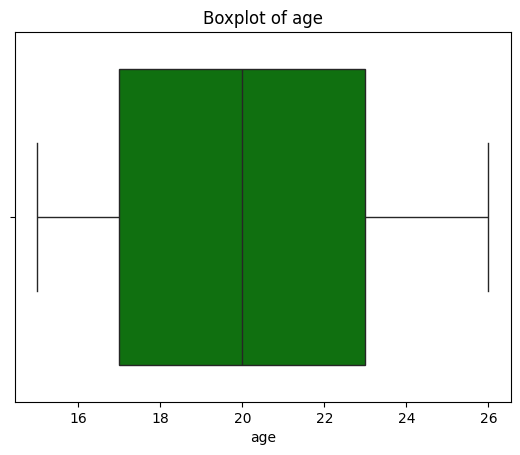

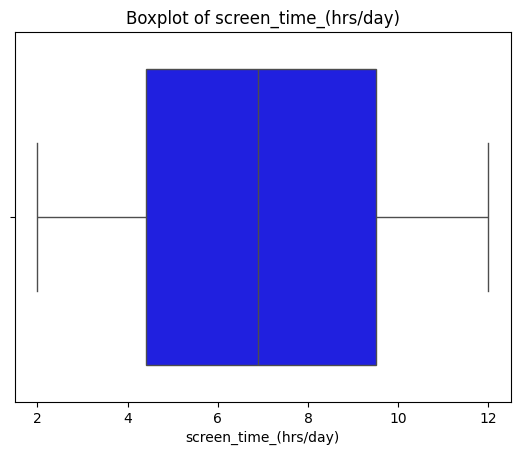

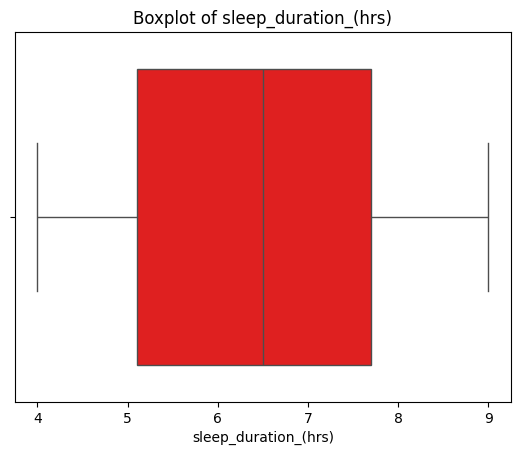

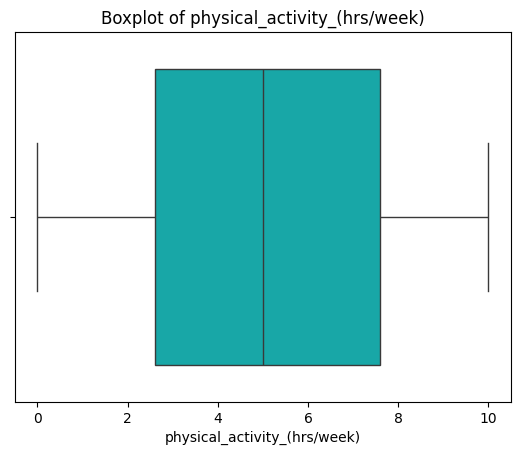

In [15]:
colors=['g', 'b', 'r', 'c', 'm', 'y', 'k']
for i,col in enumerate(numeric_col):
    sns.boxplot(x=df[col],color=colors[i%len(colors)])
    plt.title("Boxplot of {}".format(col))
    plt.show()

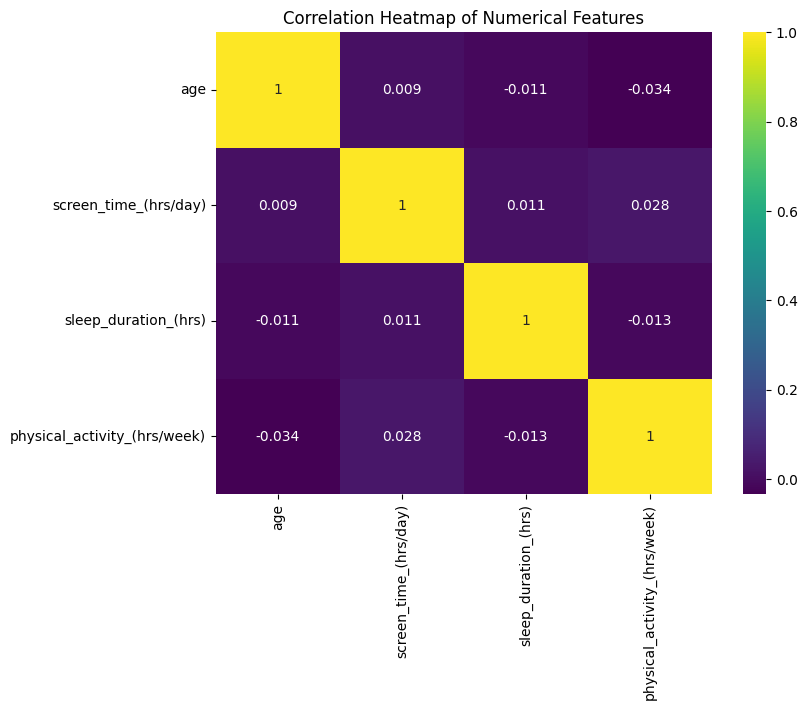

In [16]:

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[["age", "screen_time_(hrs/day)", "sleep_duration_(hrs)", "physical_activity_(hrs/week)"]].corr(), annot=True, cmap="viridis")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

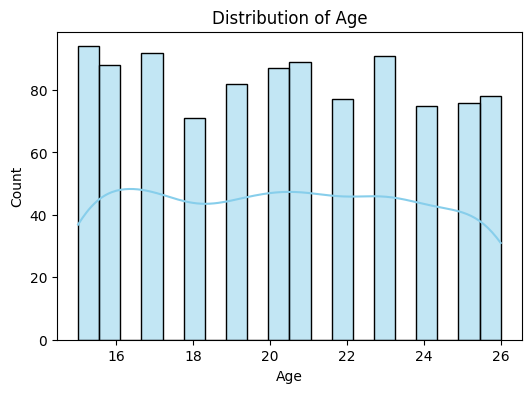

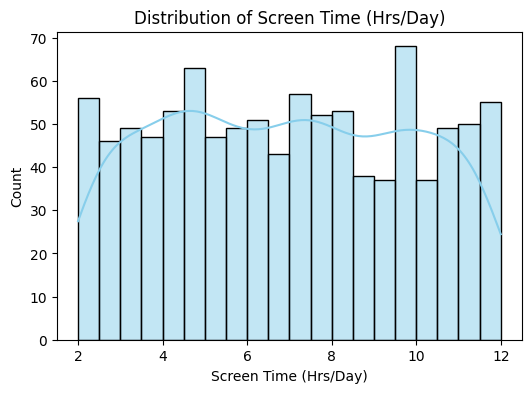

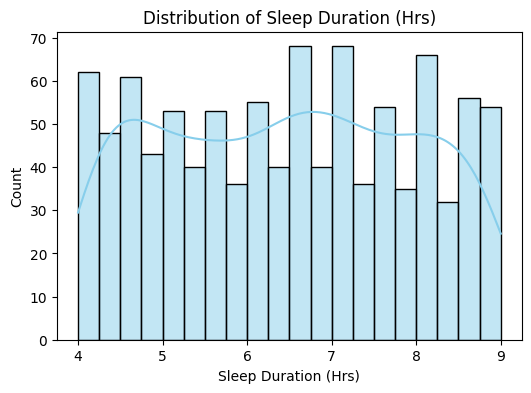

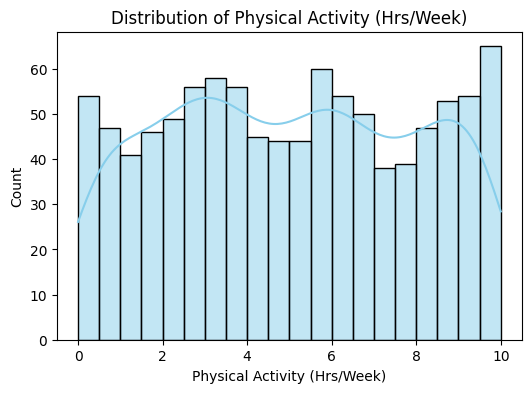

In [17]:
# Histograms for Numerical Features
num_cols = ["age", "screen_time_(hrs/day)", "sleep_duration_(hrs)", "physical_activity_(hrs/week)"]
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20, color="skyblue")
    plt.title(f"Distribution of {col.replace('_',' ').title()}")
    plt.xlabel(col.replace('_',' ').title())
    plt.ylabel("Count")
    plt.show()

### Feature Engineering

In [18]:
def z_score(df,columns):
    df_normalized=df.copy()
    for col in columns:
        mean=df[col].mean()
        std=df[col].std()
        df_normalized[col]=(df[col]-mean)/std
    return df_normalized
df_normalized=z_score(df,numeric_col)


In [19]:
df_normalized.head()


,name,gender,age,education_level,screen_time_(hrs/day),sleep_duration_(hrs),physical_activity_(hrs/week),stress_level,anxious_before_exams,academic_performance_change
0,Aarav,Male,-1.543969,Class 8,0.065632,1.670205,1.461398,Medium,No,Same
1,Meera,Female,1.346276,MSc,-1.241509,-0.989357,-1.644039,Medium,No,Same
2,Ishaan,Male,-0.098846,BTech,0.891196,-0.716581,0.403502,Medium,No,Same
3,Aditya,Male,-0.098846,BA,1.338376,-0.580194,0.164622,High,Yes,Same
4,Anika,Female,-0.965920,Class 11,-1.413502,-0.716581,-0.654394,Medium,Yes,Same


In [20]:
cat_col=df.select_dtypes(include=['object']).columns
cat_col

Index(['name', 'gender', 'education_level', 'stress_level',
       'anxious_before_exams', 'academic_performance_change'],
      dtype='object')

In [21]:
df_normalized['gender'] = df_normalized['gender'].apply(lambda x: 1 if x.lower().strip() == 'male' else 0)
df_normalized.head()



,name,gender,age,education_level,screen_time_(hrs/day),sleep_duration_(hrs),physical_activity_(hrs/week),stress_level,anxious_before_exams,academic_performance_change
0,Aarav,1,-1.543969,Class 8,0.065632,1.670205,1.461398,Medium,No,Same
1,Meera,0,1.346276,MSc,-1.241509,-0.989357,-1.644039,Medium,No,Same
2,Ishaan,1,-0.098846,BTech,0.891196,-0.716581,0.403502,Medium,No,Same
3,Aditya,1,-0.098846,BA,1.338376,-0.580194,0.164622,High,Yes,Same
4,Anika,0,-0.965920,Class 11,-1.413502,-0.716581,-0.654394,Medium,Yes,Same


In [22]:

df_normalized['education_level'] = df_normalized['education_level'].astype(str).str.lower().str.strip()
edu_uq = df_normalized['education_level'].unique()
edu_map = {value: idx for idx, value in enumerate(edu_uq)}
df_normalized['education_level'] = df_normalized['education_level'].map(edu_map)

In [23]:
stress_uq = df['stress_level'].str.lower().unique()
stress_map = {value: idx for idx, value in enumerate(stress_uq)}
df_normalized['stress_level'] = df['stress_level'].str.lower().map(stress_map)
df_normalized.head()

,name,gender,age,education_level,screen_time_(hrs/day),sleep_duration_(hrs),physical_activity_(hrs/week),stress_level,anxious_before_exams,academic_performance_change
0,Aarav,1,-1.543969,0,0.065632,1.670205,1.461398,0,No,Same
1,Meera,0,1.346276,1,-1.241509,-0.989357,-1.644039,0,No,Same
2,Ishaan,1,-0.098846,2,0.891196,-0.716581,0.403502,0,No,Same
3,Aditya,1,-0.098846,3,1.338376,-0.580194,0.164622,1,Yes,Same
4,Anika,0,-0.965920,4,-1.413502,-0.716581,-0.654394,0,Yes,Same


In [24]:
df_normalized['anxious_before_exams']=df_normalized['anxious_before_exams'].str.lower().map({'yes':1,'no':0})
df_normalized.head()

,name,gender,age,education_level,screen_time_(hrs/day),sleep_duration_(hrs),physical_activity_(hrs/week),stress_level,anxious_before_exams,academic_performance_change
0,Aarav,1,-1.543969,0,0.065632,1.670205,1.461398,0,0,Same
1,Meera,0,1.346276,1,-1.241509,-0.989357,-1.644039,0,0,Same
2,Ishaan,1,-0.098846,2,0.891196,-0.716581,0.403502,0,0,Same
3,Aditya,1,-0.098846,3,1.338376,-0.580194,0.164622,1,1,Same
4,Anika,0,-0.965920,4,-1.413502,-0.716581,-0.654394,0,1,Same


### Model Building

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import numpy as np

features = df_normalized.drop(['name', 'academic_performance_change'], axis=1)
pca = PCA()
pca.fit(features)
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
pca = PCA(n_components=n_components)
x_pca = pca.fit_transform(features)
df_normalized['academic_performance_change'] = df_normalized['academic_performance_change'].apply(lambda x: 1 if x.lower() == 'same' else 0)
y = df_normalized['academic_performance_change']

X_train, X_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prb = model.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, y_pred)
print(f"accuracy_score:{acc:2f}")


accuracy_score:0.605000




## Key Insights
- Most students are in the age range of 15-26, with a balanced gender distribution.
- Average screen time is around 7 hours per day, with some students exceeding 10 hours.
- Sleep duration varies, with a mean of about 6.5 hours per night.
- Physical activity shows a wide range, with some students reporting very low activity.
- A significant portion of students report medium to high stress levels.
- Exam anxiety is present in a notable subset of students.
- Academic performance changes are tracked and analyzed.



## Conclusion
This analysis provides a comprehensive overview of student mental health during online learning. Key findings highlight the importance of balanced screen time, adequate sleep, and physical activity in managing stress and maintaining academic performance. The insights can inform educators, policymakers, and students themselves about areas needing attention for better mental health outcomes.

**If you found this notebook helpful, please give it an upvote! 👍 It motivates me to share more insights.**

✨ **Quick Tips:**
- Tweak the code to explore new patterns or features.
- Try segmenting by education level or gender for deeper insights.
- Drop a comment if you have questions or suggestions—let's connect! 💬

Your support means a lot. Happy coding! 📊
